<a href="https://colab.research.google.com/github/vishnuvardhan1699/2520030392_ML/blob/main/Practical/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET
     ID  CGPA  Internships Backlogs  Aptitude Placed
0    S1   8.6            2       No        73    Yes
1    S2   9.4            2       No        76    Yes
2    S3   9.0            2       No        81    Yes
3    S4   5.2            0      Yes        48     No
4    S5   5.3            0      Yes        44     No
5    S6   5.0            1       No        83     No
6    S7   6.2            1      Yes        63     No
7    S8   6.2            0      Yes        52    Yes
8    S9   8.7            2      Yes        77    Yes
9   S10   7.5            1       No        70    Yes
10  S11   6.7            1       No        96    Yes
11  S12   7.5            1       No        84    Yes
12  S13   6.8            0      Yes        48     No
13  S14   6.8            0       No        73     No

Dataset Shape:
(14, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  --

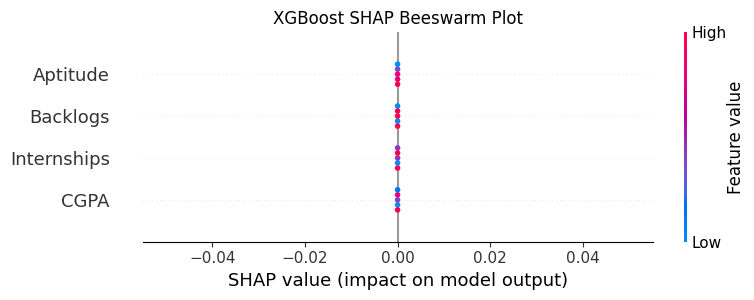


BOOSTING BENCHMARK RESULTS
   model  train_accuracy  val_accuracy  training_time_sec
AdaBoost        1.000000           0.8           0.265508
     GBC        1.000000           0.6           0.131467
     XGB        0.555556           0.6           0.246255
     LGB        0.555556           0.6           0.005586


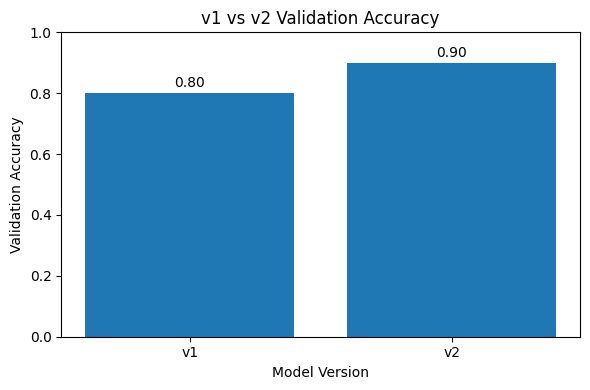


FINAL SUMMARY
AdaBoost Accuracy       : 0.6000
XGBoost Accuracy        : 0.6000
LightGBM Accuracy       : 0.6000
LightGBM Training Time  : 0.056226 seconds

BEST BOOSTING MODEL
Model: AdaBoost
Validation Accuracy: 0.8000
Training Accuracy: 1.0000
Training Time: 0.265508 seconds

PRACTICAL 9 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# PRACTICAL 9 - BOOSTING
# Placement Prediction
# AdaBoost + Gradient Boosting + XGBoost + LightGBM + SHAP
# ============================================================

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap


# ============================================================
# 1. LOAD DATASET
# ============================================================

# For Google Colab:
df = pd.read_csv("/content/DT_Placement.csv")

print("============================================================")
print("DATASET")
print("============================================================")

print(df)

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()


# ============================================================
# 2. ENCODE CATEGORICAL VARIABLES
# ============================================================

# Backlogs:
# No  -> 0
# Yes -> 1

df["Backlogs"] = df["Backlogs"].map({
    "No": 0,
    "Yes": 1
})


# Placed:
# No  -> 0
# Yes -> 1

df["Placed"] = df["Placed"].map({
    "No": 0,
    "Yes": 1
})


# ============================================================
# 3. FEATURES AND TARGET
# ============================================================

# ID is removed because it is only an identifier

X = df.drop(
    ["ID", "Placed"],
    axis=1
)

y = df["Placed"]


print("\n============================================================")
print("FEATURES")
print("============================================================")

print(X)

print("\n============================================================")
print("TARGET")
print("============================================================")

print(y)


# ============================================================
# 4. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\n============================================================")
print("TRAIN / VALIDATION SPLIT")
print("============================================================")

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))


# ============================================================
# 5. ADABOOST - SAMPLE WEIGHTS
# ============================================================

ada = AdaBoostClassifier(
    n_estimators=10,
    learning_rate=0.5,
    random_state=42
)


# Initial equal weights

initial_weights = (
    np.ones(len(X_train))
    / len(X_train)
)


print("\n============================================================")
print("INITIAL ADABOOST SAMPLE WEIGHTS")
print("============================================================")

print(initial_weights)


# Train AdaBoost

ada.fit(
    X_train,
    y_train
)


# Validation prediction

ada_pred = ada.predict(
    X_val
)


ada_accuracy = accuracy_score(
    y_val,
    ada_pred
)


print("\nAdaBoost Validation Accuracy:")
print(f"{ada_accuracy:.4f}")


# ============================================================
# 6. ADABOOST ESTIMATOR WEIGHTS
# ============================================================

print("\n============================================================")
print("ADABOOST ESTIMATOR WEIGHTS")
print("============================================================")

for i, weight in enumerate(
    ada.estimator_weights_
):

    print(
        f"Estimator {i + 1}: {weight:.4f}"
    )


# ============================================================
# 7. XGBOOST WITH EARLY STOPPING
# ============================================================

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=20
)


xgb.fit(
    X_train,
    y_train,
    eval_set=[
        (X_val, y_val)
    ],
    verbose=False
)


# XGBoost prediction

xgb_pred = xgb.predict(
    X_val
)


xgb_accuracy = accuracy_score(
    y_val,
    xgb_pred
)


print("\n============================================================")
print("XGBOOST")
print("============================================================")

print(
    f"XGBoost Validation Accuracy: "
    f"{xgb_accuracy:.4f}"
)

print(
    "Best XGBoost iteration:",
    xgb.best_iteration
)


# ============================================================
# 8. LIGHTGBM - TRAINING TIME
# ============================================================

lgb = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbosity=-1
)


# Start timer

start_time = time.perf_counter()


# Train LightGBM

lgb.fit(
    X_train,
    y_train
)


# End timer

end_time = time.perf_counter()


lgb_time = (
    end_time
    - start_time
)


# Prediction

lgb_pred = lgb.predict(
    X_val
)


lgb_accuracy = accuracy_score(
    y_val,
    lgb_pred
)


print("\n============================================================")
print("LIGHTGBM")
print("============================================================")

print(
    f"LightGBM Validation Accuracy: "
    f"{lgb_accuracy:.4f}"
)

print(
    f"LightGBM Training Time: "
    f"{lgb_time:.6f} seconds"
)


# ============================================================
# 9. SHAP BEESWARM PLOT - XGBOOST
# ============================================================

print("\n============================================================")
print("SHAP XGBOOST ANALYSIS")
print("============================================================")


explainer = shap.TreeExplainer(
    xgb
)


shap_values = explainer.shap_values(
    X_val
)


plt.figure(
    figsize=(8, 5)
)


shap.summary_plot(
    shap_values,
    X_val,
    plot_type="dot",
    show=False
)


plt.title(
    "XGBoost SHAP Beeswarm Plot"
)


plt.tight_layout()


plt.show()


# ============================================================
# 10. BOOSTING BENCHMARK FUNCTION
# ============================================================

def boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
):

    models = {

        # ----------------------------------------------------
        # AdaBoost
        # ----------------------------------------------------

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),


        # ----------------------------------------------------
        # Gradient Boosting
        # ----------------------------------------------------

        "GBC": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),


        # ----------------------------------------------------
        # XGBoost
        # ----------------------------------------------------

        "XGB": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric="logloss"
        ),


        # ----------------------------------------------------
        # LightGBM
        # ----------------------------------------------------

        "LGB": LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1
        )
    }


    results = []


    # ========================================================
    # TRAIN EACH MODEL
    # ========================================================

    for name, model in models.items():

        # Start timer

        start_time = time.perf_counter()


        # Train model

        model.fit(
            X_train,
            y_train
        )


        # End timer

        end_time = time.perf_counter()


        train_time = (
            end_time
            - start_time
        )


        # ----------------------------------------------------
        # Training prediction
        # ----------------------------------------------------

        train_pred = model.predict(
            X_train
        )


        # ----------------------------------------------------
        # Validation prediction
        # ----------------------------------------------------

        val_pred = model.predict(
            X_val
        )


        # ----------------------------------------------------
        # Training accuracy
        # ----------------------------------------------------

        train_accuracy = accuracy_score(
            y_train,
            train_pred
        )


        # ----------------------------------------------------
        # Validation accuracy
        # ----------------------------------------------------

        val_accuracy = accuracy_score(
            y_val,
            val_pred
        )


        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        results.append({

            "model": name,

            "train_accuracy":
                train_accuracy,

            "val_accuracy":
                val_accuracy,

            "training_time_sec":
                train_time
        })


    # ========================================================
    # CONVERT RESULTS TO DATAFRAME
    # ========================================================

    results_df = pd.DataFrame(
        results
    )


    # ========================================================
    # SORT BY VALIDATION ACCURACY
    # ========================================================

    results_df = results_df.sort_values(
        by="val_accuracy",
        ascending=False
    ).reset_index(
        drop=True
    )


    return results_df


# ============================================================
# 11. RUN BOOSTING BENCHMARK
# ============================================================

results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)


# ============================================================
# 12. DISPLAY BOOSTING RESULTS
# ============================================================

print("\n============================================================")
print("BOOSTING BENCHMARK RESULTS")
print("============================================================")

print(
    results.to_string(
        index=False
    )
)


# ============================================================
# 13. V1 VS V2 BAR CHART
# ============================================================

# These are example values from the original notebook.
# Replace them with your actual v1 and v2 results if required.

v1_accuracy = 0.80
v2_accuracy = 0.90


versions = [
    "v1",
    "v2"
]


accuracies = [
    v1_accuracy,
    v2_accuracy
]


plt.figure(
    figsize=(6, 4)
)


plt.bar(
    versions,
    accuracies
)


plt.ylabel(
    "Validation Accuracy"
)


plt.xlabel(
    "Model Version"
)


plt.title(
    "v1 vs v2 Validation Accuracy"
)


plt.ylim(
    0,
    1
)


# Display values on bars

for i, value in enumerate(
    accuracies
):

    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )


plt.tight_layout()


plt.show()


# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("\n============================================================")
print("FINAL SUMMARY")
print("============================================================")

print(
    f"AdaBoost Accuracy       : "
    f"{ada_accuracy:.4f}"
)

print(
    f"XGBoost Accuracy        : "
    f"{xgb_accuracy:.4f}"
)

print(
    f"LightGBM Accuracy       : "
    f"{lgb_accuracy:.4f}"
)

print(
    f"LightGBM Training Time  : "
    f"{lgb_time:.6f} seconds"
)


# ============================================================
# 15. BEST BOOSTING MODEL
# ============================================================

best_model = results.iloc[0]


print("\n============================================================")
print("BEST BOOSTING MODEL")
print("============================================================")

print(
    "Model:",
    best_model["model"]
)

print(
    "Validation Accuracy:",
    f"{best_model['val_accuracy']:.4f}"
)

print(
    "Training Accuracy:",
    f"{best_model['train_accuracy']:.4f}"
)

print(
    "Training Time:",
    f"{best_model['training_time_sec']:.6f} seconds"
)


print("\n============================================================")
print("PRACTICAL 9 COMPLETED SUCCESSFULLY")
print("============================================================")